In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.signal
from matplotlib.colors import Normalize, LogNorm
from matplotlib.animation import FuncAnimation
import cwt2D1T as cwt
import os
from astropy.io import fits
import re
from datetime import datetime
import scipy.signal
from scipy.interpolate import griddata
from scipy.optimize import curve_fit
%matplotlib ipympl

In [2]:
data_filtered = np.load('./data/comp_filtered.npy')
comp_data = np.load('./data/comp_data.npy')
mask = np.ones_like(comp_data)
mask[comp_data==0] = 0
dx = 3.234
dy = 3.234
dt = 30

# 数据展示与预处理

In [3]:
comp_fits_dir = "../data/fits_20120327_morton/"
comp_fits_list = os.listdir(comp_fits_dir)
comp_fits_list.sort()
# print(comp_fits_list[35:170])

In [4]:
with fits.open(os.path.join(comp_fits_dir, comp_fits_list[0])) as hdul:
    v_data = hdul[3].data
    header = hdul[0].header
CRVAL1 = header['CRVAL1']
CRVAL2 = header['CRVAL2']
CRPIX1 = header['CRPIX1']
CRPIX2 = header['CRPIX2']
CDELT1 = 3.234
CDELT2 = 3.234
ny, nx = v_data.shape

left = CRVAL1 - (CRPIX1 - 1) * CDELT1
right = left + nx * CDELT1
bottom = CRVAL2 - (CRPIX2 - 1) * CDELT2
top = bottom + ny * CDELT2
extent = [left, right, bottom, top]

In [ ]:
fig, ax = plt.subplots(figsize=(6, 6))
im = ax.imshow(v_data, cmap='coolwarm', vmin=-5, vmax=5, origin='lower', extent=extent)
ax.set_xlabel('Y [Mm]')
ax.set_ylabel('X [Mm]')
ax.set_title(header['TIMESYS'] + header['DATE-OBS'] + header['TIME-OBS'])
ax.set_aspect('equal')
fig.subplots_adjust(right=0.85)  # 给 colorbar 留出空间
cax = fig.add_axes([0.88, 0.15, 0.04, 0.7])  # 手动调整位置和高度
plt.colorbar(im, cax=cax, label='Doppler Velocity [Km/s]')
fig.savefig('./fig/毕业论文材料/全日冕多普勒速度图.eps', format='eps')
# fig.savefig('./fig/毕业论文材料/全日冕多普勒速度图.png', dpi=300)

In [ ]:
plt.close(fig)

In [ ]:
y_start, y_end = 530, 590
x_start, x_end = 250, 370
v_data_slice = v_data[y_start:y_end, x_start:x_end]  # 切片数据

left_new = left + x_start * CDELT1
right_new = left_new + (x_end - x_start) * CDELT1
bottom_new = bottom + y_start * CDELT2
top_new = bottom_new + (y_end - y_start) * CDELT2
extent_new = [left_new, right_new, bottom_new, top_new]

fig, ax = plt.subplots(figsize=(6, 4))
im = ax.imshow(v_data_slice, cmap='coolwarm', vmin=-5, vmax=5, origin='lower', extent=extent_new)

ax.set_xlabel('Y [Mm]')
ax.set_ylabel('X [Mm]')
ax.set_title(header['TIMESYS'] + header['DATE-OBS'] + header['TIME-OBS'])
ax.set_aspect('equal')

# 调整 colorbar
fig.subplots_adjust(right=0.85)
cax = fig.add_axes([0.88, 0.225, 0.02, 0.55])
plt.colorbar(im, cax=cax, label='Doppler Velocity [Km/s]')
# fig.savefig('./fig/毕业论文材料/裁剪后多普勒速度图.eps', format='eps')
fig.savefig('./fig/毕业论文材料/裁剪后多普勒速度图.png', dpi=300)

In [ ]:
plt.close(fig)

# 数据插值

In [ ]:
comp_fits_dir = "../data/fits_20120327_morton/"
comp_fits_list = os.listdir(comp_fits_dir)
comp_fits_list.sort()
already_crop_data = False

for i, comp_fits in enumerate(comp_fits_list):
    from astropy.io import fits
    hdul = fits.open(comp_fits_dir+comp_fits)
    obstime = hdul[0].header['DATE-OBS']+' '+hdul[0].header['TIME-OBS']
    if i == 0:
        print(hdul[0].header['CDELT1'])
    doppler_map = hdul[3].data
    enhanced_intensity = hdul[1].data
    if not already_crop_data:
        sequence_doppler_map = np.copy(doppler_map[530:590, 250:370])
        already_crop_data = True
    else:
        sequence_doppler_map = np.dstack([sequence_doppler_map, doppler_map[530:590, 250:370]])

comp_data = np.transpose(sequence_doppler_map, (0,1,2))[:, :, 35:170]

In [ ]:
def get_time(files):
    times = []
    for file in files:
        match = re.search(r'\d{8}\.\d{6}', file)
        if match:
            times.append(datetime.strptime(match.group(), '%Y%m%d.%H%M%S'))
        else:
            times.append(datetime.min)
    return np.array(times)
time_seq = get_time(comp_fits_list[35:170])
time_seq -= time_seq[0]
time_seq = np.array([t.total_seconds() for t in time_seq])
time_seq_interp = 30*np.arange(135)

In [ ]:
from scipy.interpolate import  PchipInterpolator
comp_data_interp = np.zeros_like(comp_data)
for i in range(comp_data.shape[0]):
    for j in range(comp_data.shape[1]):
        data_seq = comp_data[i, j, :]
        f = PchipInterpolator(time_seq, data_seq, extrapolate=True)
        comp_data_interp[i, j, :] = f(time_seq_interp)

In [ ]:
np.save('./data/comp_data_interp.npy', comp_data_interp)

# 数据滤波

In [ ]:
comp_data = np.load('./data/comp_data_interp.npy')
fft_data = np.fft.fftn(comp_data, axes=[-1])
freq = np.fft.fftfreq(comp_data.shape[-1], 30)
f0 = 3.5e-3
delta_f = 0.4e-3
gaussian_filter = (np.exp(-(freq - f0)**2 / delta_f**2) + np.exp(-(freq + f0)**2 / delta_f**2))[None, None, :]
fft_data_filtered = gaussian_filter * fft_data
data_filtered = np.fft.ifftn(fft_data_filtered, axes=[-1]).real
np.save('./data/comp_filtered.npy', data_filtered)

In [ ]:
y_start, y_end = 530, 590
x_start, x_end = 250, 370
v_data_slice = v_data[y_start:y_end, x_start:x_end]  # 切片数据

left_new = left + x_start * CDELT1
right_new = left_new + (x_end - x_start) * CDELT1
bottom_new = bottom + y_start * CDELT2
top_new = bottom_new + (y_end - y_start) * CDELT2
extent_new = [left_new, right_new, bottom_new, top_new]

fig, ax = plt.subplots(figsize=(6, 4))
im = ax.imshow(data_filtered[:, :, 0], cmap='coolwarm', vmin=-1, vmax=1, origin='lower', extent=extent_new)

ax.set_xlabel('Y [Mm]')
ax.set_ylabel('X [Mm]')
ax.set_title(header['TIMESYS'] + header['DATE-OBS'] + header['TIME-OBS'])
ax.set_aspect('equal')

# 调整 colorbar
fig.subplots_adjust(right=0.85)
cax = fig.add_axes([0.88, 0.225, 0.02, 0.55])
plt.colorbar(im, cax=cax, label='Doppler Velocity [Km/s]')
fig.savefig('./fig/毕业论文材料/滤波后多普勒速度图.eps', format='eps')
# fig.savefig('./fig/毕业论文材料/滤波后多普勒速度图.png', dpi=300)

In [ ]:
plt.close(fig)

# 相速度计算

In [ ]:
comp_data = np.load('./data/comp_data_interp.npy')
data_filtered = np.load('./data/comp_filtered.npy')

In [ ]:
kx_array = np.linspace(-0.295, 0.295, 60)/2/np.pi
ky_array = np.linspace(-0.9, 0.9, 5)/2/np.pi
omega_array = np.linspace(0.01, 0.03, 40)/2/np.pi
# kx_array = np.linspace(-0.9, 0.9, 60)/2/np.pi
# ky_array = np.linspace(-0.9, 0.9, 5)/2/np.pi
# omega_array = np.linspace(0.01, 0.1, 40)/2/np.pi

In [ ]:
psd = cwt.full_3d_psd(data_filtered, kx_array*2*np.pi, ky_array*2*np.pi, omega_array*2*np.pi, dx, dy, dt, 1, 3, 3, (60, 5, 40))
psd_st_mean = np.mean(psd[25:35, 50:70, 80:110, ...], axis=(0, 1, 2))
psd_kx_omega = np.trapezoid(psd_st_mean, x=ky_array*2*np.pi, axis=1) / cwt.c_psi(1, 3, 3) / 27

In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))
# im = ax.imshow(psd_kx_omega.T, cmap='jet', origin='lower',
#                extent=(kx_array[0], kx_array[-1], omega_array[0], omega_array[-1]), norm=LogNorm(vmin=0.0005))
kx_grid, omega_grid = np.meshgrid(kx_array, omega_array, indexing='ij')
x = kx_grid.ravel()
y = omega_grid.ravel()
z = np.log10(psd_kx_omega*1e3).ravel()
im = ax.tricontourf(x, y, z, levels=60, cmap='jet')
ax.plot(-1*np.linspace(omega_array[0], omega_array[-5], 10)/0.444, np.linspace(omega_array[0], omega_array[-5], 10),
        linestyle='--', color='k', label='Morton, outward, 444Km/s')
ax.plot(np.linspace(omega_array[0], omega_array[-5], 10)/0.365, np.linspace(omega_array[0], omega_array[-5], 10),
        linestyle=':', color='k', label='Morton, inward, 365Km/s')
ax.plot(-1*np.linspace(omega_array[0], omega_array[-5], 10)/0.150, np.linspace(omega_array[0], omega_array[-5], 10),
        linestyle='-', color='k', label=r'outward, $\approx$150Km/s')
ax.plot(np.linspace(omega_array[0], omega_array[-5], 10)/0.110, np.linspace(omega_array[0], omega_array[-5], 10),
        linestyle='-.', color='k', label=r'inward, $\approx$110Km/s')
ax.axvspan(xmin=-(1/60/3.234), xmax=1/60/3.234, color='white')
ax.set_xlabel('kx [1/Mm]')
ax.set_ylabel('f [Hz]')
ax.grid(True)
ax.set_aspect('auto')
ax.legend(loc='upper left')
plt.colorbar(im, ax=ax, label=r'$log10(PSD/[Km^3\cdot s^{-1}])$')
fig.savefig('./fig/毕业论文材料/波数-频率图.eps', format='eps')
# fig.savefig('./fig/波数-频率图.png', dpi=300)

In [ ]:
plt.close(fig)

In [ ]:
psd_kx = np.mean(psd_kx_omega, axis=-1)
# psd_kx[32] = psd_kx[31]
# psd_kx[33] = psd_kx[31]
# psd_kx[27:33] = 0

In [ ]:
# kx_array_fit = np.delete(kx_array, [28, 31, 32, 33])
# psd_kx_fit = np.delete(psd_kx, [28, 31, 32, 33])

In [ ]:
def four_gauss(x, A1, mu1, sigma1,
               A2, mu2, sigma2,
               A3, mu3, sigma3,
               A4, mu4, sigma4, c):
    g1 = A1 * np.exp(-(x - mu1)**2 / (2 * sigma1**2))
    g2 = A2 * np.exp(-(x - mu2)**2 / (2 * sigma2**2))
    g3 = A3 * np.exp(-(x - mu3)**2 / (2 * sigma3**2))
    g4 = A4 * np.exp(-(x - mu4)**2 / (2 * sigma4**2))
    return g1 + g2 + g3 + g4 + c

def two_gauss(x, A1, mu1, sigma1,
               A2, mu2, sigma2):
    g1 = A1 * np.exp(-(x - mu1)**2 / (2 * sigma1**2))
    g2 = A2 * np.exp(-(x - mu2)**2 / (2 * sigma2**2))
    return g1 + g2

initial_param = [0.145, -0.025, 0.015, 0.889, -0.0073, 0.0067, 0.27, 0.0125, 0.0067, 0.07, 0.032, 0.032, 0]
# initial_param = [0.889, -0.0073, 0.0067, 0.27, 0.0125, 0.0067]

# lower_bounds = [0, -0.04, 0,
#                 0, -0.02, 0,
#                 0, 0, 0,
#                 0.07,  0.031, 0, -np.inf]
# upper_bounds = [np.inf, -0.02, np.inf,
#                 np.inf, 0.0, np.inf,
#                 np.inf, 0.02, np.inf,
#                 np.inf, 0.033, 0.04, np.inf]

popt, pcov = curve_fit(four_gauss, kx_array, psd_kx, p0=initial_param, maxfev=100000)


In [ ]:
popt

In [ ]:
params = popt[0:-1].reshape((4, 3))

In [ ]:
mu = params[:, 1]
sigma = np.abs(params[:, 2])
print(mu)
print(sigma)

In [ ]:
v_p = np.abs(0.0035/mu)
sigma_vp = np.abs(v_p * np.sqrt((0.0004/0.0035/np.sqrt(2))**2 + (sigma/mu)**2))
print(1000*v_p)
print(1000*sigma_vp)

In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(kx_array, psd_kx, marker='o', facecolors='none', edgecolors='k', label=r'$PSD\left(k_x\right)$')
ax.plot(np.linspace(-0.05, 0.05, 1000), four_gauss(np.linspace(-0.05, 0.05, 1000), *popt), label='gaussian fit')
ax.set_xlabel(r'$k_x$ [1/Mm]')
ax.set_ylabel(r'$PSD\left(k_x\right)$ [$Km^3\cdot s^{-1}$]')
ax.grid()
ax.legend()
fig.savefig('./fig/毕业论文材料/波数拟合.eps', format='eps')

In [ ]:
plt.close(fig)

In [ ]:
kx_va_in = np.linspace(0.005, 0.015, 20)
kx_va_out = np.sort(-1*kx_va_in)
kx_vs_in = np.linspace(0.02, 0.1, 20)
kx_vs_out = np.sort(-1*kx_vs_in)

ky_array = np.linspace(-0.9, 0.9, 5)/2/np.pi
omega_array = np.linspace(0.01, 0.1, 40)/2/np.pi

In [ ]:
psd_va_out = cwt.full_3d_psd(data_filtered, 2*np.pi*kx_va_in, 2*np.pi*ky_array, 2*np.pi*omega_array, dx, dy, dt, 1, 3, 3, (20, 5, 40))

In [ ]:
psd_va_out = np.trapezoid(psd_va_out, x=2*np.pi*ky_array, axis=-2)

In [ ]:
fig, ax = plt.subplots()
ax.plot(kx_va_out, np.mean(psd_va_out[25:35, 50:70, 80:110, ...], axis=(0, 1, 2, 4)))

In [ ]:
plt.close(fig)

## 分块平均PSD

In [ ]:
def split_array(m, n):
    q, r = divmod(m, n)
    index = []
    start = 0

    for i in range(n):
        length = q + 1 if i < r else q
        index.append((start, start + length))
        start += length

    return index
def block_average(data, blocks=(1, 1)):
    shape = (blocks[0], blocks[1]) + data.shape[2:]
    block_average_data = np.zeros(shape)
    x_indexes = split_array(data.shape[0], blocks[0])
    y_indexes = split_array(data.shape[1], blocks[1])
    for i, x_index in enumerate(x_indexes):
        for j, y_index in enumerate(y_indexes):
            block_average_data[i, j, ...] = np.mean(data[x_index[0]:x_index[1], y_index[0]:y_index[1], ...], axis=(0, 1))
    return block_average_data

In [ ]:
psd_int_ky = np.trapezoid(psd, ky_array*2*np.pi, axis=-2)
psd_block = block_average(psd_int_ky, blocks=(6, 12))
del psd_int_ky

In [ ]:
plt.close()
with plt.ioff():
    fig, axs = plt.subplots(nrows=6, ncols=12, figsize=(24, 12), sharex=True, sharey=True)
    axs = axs[::-1, :]
    plt.subplots_adjust(right=0.92, top=0.90, wspace=0.3, hspace=0.3)

    kx_grid, omega_grid = np.meshgrid(kx_array, omega_array, indexing='ij')
    x = kx_grid.ravel()
    y = omega_grid.ravel()
    vmin = np.min(np.log10(psd_block*1e3))
    vmax = np.max(np.log10(psd_block*1e3))
    norm = Normalize(vmin=vmin, vmax=vmax)

    cbar_ax = fig.add_axes([0.94, 0.1, 0.015, 0.8])
    cbar = None

    for k in range(psd_block.shape[2]):
        for i in range(6):
            for j in range(12):
                axs[i, j].clear()
                data = psd_block[i, j, k]
                z = np.log10(data*1e3).ravel()
                mesh = axs[i, j].tricontourf(x, y, z, levels=60, cmap='jet', norm=norm)
                if i==0:
                    axs[i, j].set_xlabel(f'{j}')
                if j==0:
                    axs[i, j].set_ylabel(f'{i}')
                if i != 0:
                    axs[i, j].tick_params(axis='x', which='both', bottom=False, labelbottom=False)
                if j != 0:
                    axs[i, j].tick_params(axis='y', which='both', left=False, labelleft=False)

        fig.suptitle(f'Filtered data, Block-average PSD - frame {k:03d}', fontsize=20, fontweight='bold', y=0.98)
        fig.supxlabel(r'$100\cdot k_x$ [1/Mm]', fontsize=16, fontweight='bold')  # 总X轴
        fig.supylabel(r'f [Hz]', fontsize=16, fontweight='bold')
        if cbar is None:
            cbar = fig.colorbar(mesh, cax=cbar_ax, label=r'log10(PSD)')
        fig.savefig(f'./fig/PSD切片/frame {k:03d}.png', dpi=150)

plt.close(fig)

# 各成分重构

In [ ]:
f_array = np.linspace(0.0023, 0.0047, 25)
kx_va_in = np.linspace(0.0052, 0.0175, 15)
kx_va_out = np.sort(-1*kx_va_in)
kx_vs_in = np.linspace(0.0175, 0.05, 15)
kx_vs_out = np.sort(-1*kx_vs_in)
ky_array = np.linspace(-0.9, 0.9, 15)

In [ ]:
def reconstruct(data, kx_array, ky_array, omega_array, dx, dy, dt, epsilon, k0, omega0, save=None):
    w = cwt.full_3d_cwt(data, kx_array, ky_array, omega_array, dx, dy, dt, epsilon, k0, omega0,
                        (len(kx_array), len(ky_array), len(omega_array)))
    data_rec = cwt.full_3d_icwt(w, kx_array, ky_array, omega_array, dx, dy, dt, epsilon, k0, omega0,
                                (len(kx_array)-1, len(ky_array)-1, len(omega_array)-1))
    del w
    if save is not None:
        np.save(save, data_rec)
    return data_rec

In [5]:
# rec_va_out = reconstruct(data_filtered, 2*np.pi*kx_va_out, ky_array, 2*np.pi*f_array, dx, dy, dt, 1, 3, 3, save='./data/rec_va_out.npy')
# rec_va_in = reconstruct(data_filtered, 2*np.pi*kx_va_in, ky_array, 2*np.pi*f_array, dx, dy, dt, 1, 3, 3, save='./data/rec_va_in.npy')
# rec_vs_out = reconstruct(data_filtered, 2*np.pi*kx_vs_out, ky_array, 2*np.pi*f_array, dx, dy, dt, 1, 3, 3, save='./data/rec_vs_out.npy')
# rec_vs_in = reconstruct(data_filtered, 2*np.pi*kx_vs_in, ky_array, 2*np.pi*f_array, dx, dy, dt, 1, 3, 3, save='./data/rec_vs_in.npy')
rec_va_out = np.load('./data/rec_va_out.npy') * mask
rec_va_in = np.load('./data/rec_va_in.npy') * mask
rec_vs_out = np.load('./data/rec_vs_out.npy') * mask
rec_vs_in = np.load('./data/rec_vs_in.npy') * mask

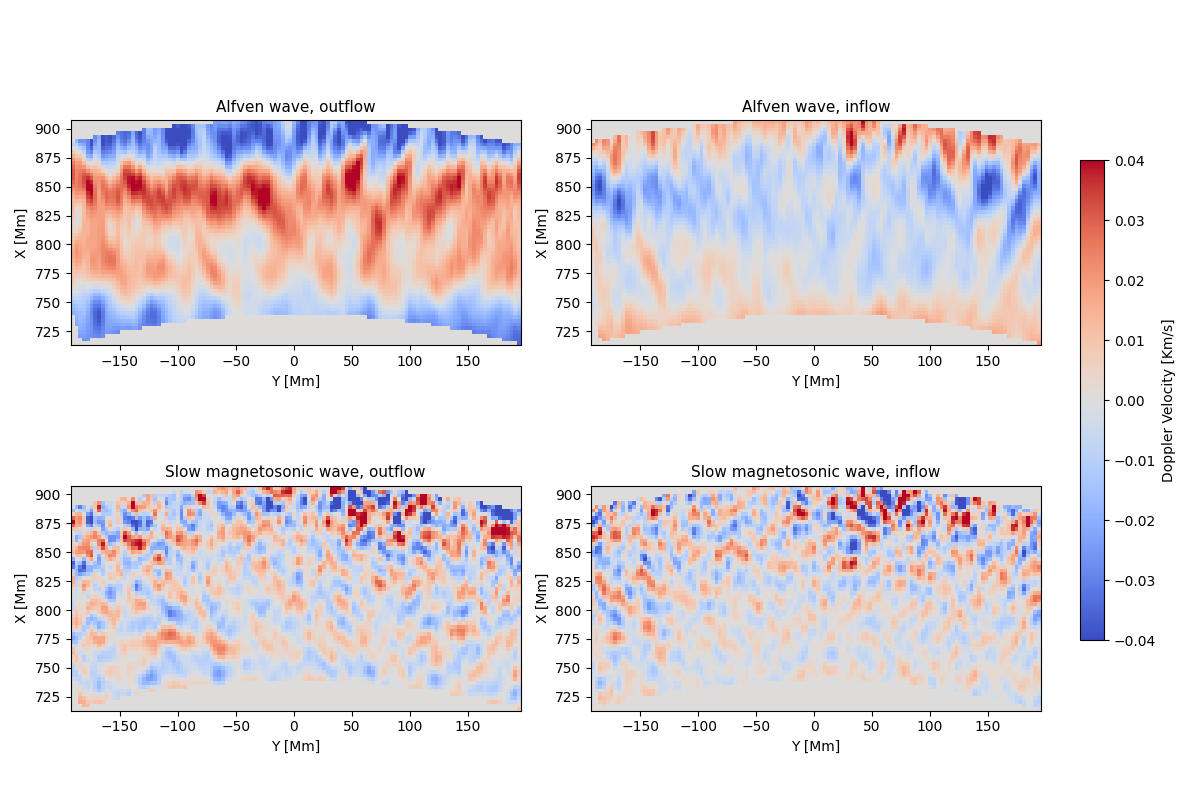

In [18]:
y_start, y_end = 530, 590
x_start, x_end = 250, 370

left_new = left + x_start * CDELT1
right_new = left_new + (x_end - x_start) * CDELT1
bottom_new = bottom + y_start * CDELT2
top_new = bottom_new + (y_end - y_start) * CDELT2
extent_new = [left_new, right_new, bottom_new, top_new]

from datetime import datetime, timedelta
original_str = 'UTC2012-03-2718:01:21'
dt = datetime.strptime(original_str, 'UTC%Y-%m-%d%H:%M:%S')

im_list = []
data_list = [rec_va_out, rec_va_in, rec_vs_out, rec_vs_in]
title_list = ['Alfven wave, outflow', 'Alfven wave, inflow', 'Slow magnetosonic wave, outflow', 'Slow magnetosonic wave, inflow']

# 保留你原有的所有变量定义和数据准备代码

fig, axs = plt.subplots(ncols=2, nrows=2, figsize=(12, 8))  # 微调figsize比例，更适合2x2布局
axs = axs.flatten()

for i in range(4):
    data = data_list[i]
    im = axs[i].imshow(data[:, :, 65], cmap='coolwarm', vmin=-0.04, vmax=0.04,
                       origin='lower', extent=extent_new)
    axs[i].set_xlabel('Y [Mm]', fontsize=10)  # 减小标签字体
    axs[i].set_ylabel('X [Mm]', fontsize=10)
    axs[i].set_title(title_list[i], fontsize=11)  # 减小子图标题字体
    axs[i].set_aspect('equal')
    im_list.append(im)

# 关键：先调用tight_layout，再调整颜色条和主标题
# rect参数：[left, bottom, right, top]，为颜色条和主标题预留空间
fig.tight_layout(rect=[0, 0, 0.88, 0.95])

# 主标题放在tight_layout预留的顶部空间
# title = fig.suptitle('UTC2012-03-2718:01:21', fontsize=14, fontweight='bold', y=0.96)

# 颜色条放在tight_layout预留的右侧空间
cax = fig.add_axes([0.90, 0.2, 0.02, 0.6])  # 调整颜色条高度，利用更多垂直空间
plt.colorbar(im, cax=cax, label='Doppler Velocity [Km/s]')
fig.savefig('./fig/毕业论文材料/各成分重构.eps', format='eps')
fig.savefig('./fig/毕业论文材料/各成分重构.png', dpi=300)

# 动画部分保持不变
# def update(frame):
#     for i in range(4):
#         im_list[i].set_data(data_list[i][:, :, frame])
#     new_dt = dt + timedelta(seconds=frame*30)
#     title.set_text(f'UTC{new_dt.strftime("%Y-%m-%d %H:%M:%S")}')
#     return im_list + [title]  # 注意：blit=True时必须返回所有更新的艺术家
#
# ani = FuncAnimation(fig, update, frames=135, interval=20, blit=True)
# ani.save('./movie/重构动画_紧凑版.mp4', fps=10, dpi=150)

In [20]:
plt.close(fig)

In [ ]:
y_start, y_end = 530, 590
x_start, x_end = 250, 370

left_new = left + x_start * CDELT1
right_new = left_new + (x_end - x_start) * CDELT1
bottom_new = bottom + y_start * CDELT2
top_new = bottom_new + (y_end - y_start) * CDELT2
extent_new = [left_new, right_new, bottom_new, top_new]

fig, ax = plt.subplots(figsize=(6, 4))
im = ax.imshow(rec_va_out[:, :, 0], cmap='coolwarm_r', vmin=-0.04, vmax=0.04, origin='lower', extent=extent_new)

ax.set_xlabel('Y [Mm]')
ax.set_ylabel('X [Mm]')
ax.set_title(header['TIMESYS'] + header['DATE-OBS'] + header['TIME-OBS'])
ax.set_aspect('equal')

# 调整 colorbar
fig.subplots_adjust(right=0.85)
cax = fig.add_axes([0.88, 0.225, 0.02, 0.55])
plt.colorbar(im, cax=cax, label='Doppler Velocity [Km/s]')

In [ ]:
plt.close(fig)

# 反射率计算

In [ ]:
Rs = 961.45/4.46*3.234
X, Y = np.meshgrid(np.arange(530, 590), np.arange(250, 370), indexing='ij')
height = np.sqrt((X-310.5)**2 + (Y-310.5)**2) * 3.234
x_grid = height/Rs
def n_e(x):
    return 1.3*1e5*(1/x**2 + 25/x**4 + 300/x**8 + 1500/x**16 + 5796/x**33.9)
rho_grid = n_e(x_grid)*1e6*1.3*1.67e-27

In [ ]:
height_plot = np.linspace(50, 250, 100)
n_e_plot = n_e(height_plot/Rs +1)
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(height_plot, n_e_plot)
ax.set_xlabel('Altitude from the solar boundary [Mm]')
ax.set_ylabel(r'$n_e$ [$cm^{-3}$]')
ax.grid()
# fig.savefig('./fig/毕业论文材料/电子密度.eps', format='eps')
fig.savefig('./fig/毕业论文材料/电子密度.png', dpi=300)

In [ ]:
plt.close(fig)

In [ ]:
flux_in = np.mean((rec_va_in - np.mean(rec_va_in, axis=2)[:, :, None])**2, axis=2) * rho_grid * 364 * 1e9
flux_out = np.mean((rec_va_out - np.mean(rec_va_out, axis=2)[:, :, None])**2, axis=2) * rho_grid * 444 * 1e9

In [ ]:
fig, ax = plt.subplots(figsize=(7, 4))
im = ax.imshow(flux_in, cmap='jet', origin='lower', extent=extent_new, norm=LogNorm(vmin=1e-7, vmax=1e-4))
ax.set_title('Inflow alfven wave average energy flux density')
ax.set_xlabel('Y [Mm]')
ax.set_ylabel('X [Mm]')
ax.set_aspect('equal')
fig.subplots_adjust(right=0.85)
cax = fig.add_axes([0.88, 0.175, 0.02, 0.65])
plt.colorbar(im, cax=cax, label=r'Energy flux density [$\mathrm{J} \cdot m^{-2} \cdot s^{-1}$]')
# fig.savefig('./fig/毕业论文材料/内传阿尔芬能流分布.eps', format='eps')
fig.savefig('./fig/毕业论文材料/内传阿尔芬能流分布.png', dpi=300)

In [ ]:
plt.close(fig)

In [ ]:
fig, ax = plt.subplots(figsize=(7, 4))
im = ax.imshow(flux_out, cmap='jet', origin='lower', extent=extent_new, norm=LogNorm(vmin=1e-7, vmax=1e-4))
ax.set_title('Outflow alfven wave average energy flux density')
ax.set_xlabel('Y [Mm]')
ax.set_ylabel('X [Mm]')
ax.set_aspect('equal')
fig.subplots_adjust(right=0.85)
cax = fig.add_axes([0.88, 0.175, 0.02, 0.65])
plt.colorbar(im, cax=cax, label=r'Energy flux density [$\mathrm{J} \cdot m^{-2} \cdot s^{-1}$]')
fig.savefig('./fig/毕业论文材料/外传阿尔芬能流分布.eps', format='eps')

In [ ]:
plt.close(fig)

In [ ]:
x_grid, y_grid = np.meshgrid(np.arange(530, 590)-310.5, np.arange(250, 370)-310.5, indexing='ij')
x_grid *= 3.234
y_grid *= 3.234
r_vec = np.arange(740, 900, 3.234)
theta_vec = np.linspace(-12, 12, 121)/180*np.pi
r_grid, theta_grid = np.meshgrid(r_vec, theta_vec, indexing='ij')
x_interp = r_grid * np.cos(theta_grid)
y_interp = r_grid * np.sin(theta_grid)
points = np.column_stack((x_grid.ravel(), y_grid.ravel()))
flux_in_polar = griddata(points, flux_in.ravel(), (x_interp, y_interp), method='cubic')*((r_vec/Rs)**2)[:, None]
flux_out_polar = griddata(points, flux_out.ravel(), (x_interp, y_interp), method='cubic')*((r_vec/Rs)**2)[:, None]

In [ ]:
fig, ax = plt.subplots(figsize=(7, 4))
im = ax.imshow(flux_in_polar, origin='lower', cmap='jet', norm=LogNorm(vmin=1e-7, vmax=1e-4),
          extent=(theta_vec[0]*180/np.pi, theta_vec[-1]*180/np.pi, r_vec[0], r_vec[-1]))
ax.set_aspect('auto')
ax.set_title('Inflow alfven wave average energy flux density')
ax.set_xlabel('Theta [degree]')
ax.set_ylabel('Heliocentric distance [Mm]')
ax.set_aspect(0.2/3.234)
fig.subplots_adjust(right=0.85)
cax = fig.add_axes([0.88, 0.25, 0.02, 0.5])
plt.colorbar(im, cax=cax, label=r'Energy flux density [$\mathrm{J} \cdot m^{-2} \cdot s^{-1}$]')
# fig.savefig('./fig/毕业论文材料/内传阿尔芬能流分布_极坐标修正.eps', format='eps')
fig.savefig('./fig/毕业论文材料/内传阿尔芬能流分布_极坐标修正.png', dpi=300)

In [ ]:
plt.close(fig)

In [ ]:
fig, ax = plt.subplots(figsize=(7, 4))
im = ax.imshow(flux_out_polar, origin='lower', cmap='jet', norm=LogNorm(vmin=1e-7, vmax=1e-4),
          extent=(theta_vec[0]*180/np.pi, theta_vec[-1]*180/np.pi, r_vec[0], r_vec[-1]))
ax.set_aspect('auto')
ax.set_title('Outflow alfven wave average energy flux density')
ax.set_xlabel('Theta [degree]')
ax.set_ylabel('Heliocentric distance [Mm]')
ax.set_aspect(0.2/3.234)
fig.subplots_adjust(right=0.85)
cax = fig.add_axes([0.88, 0.25, 0.02, 0.5])
plt.colorbar(im, cax=cax, label=r'Energy flux density [$\mathrm{J} \cdot m^{-2} \cdot s^{-1}$]')
# fig.savefig('./fig/毕业论文材料/外传阿尔芬能流分布_极坐标修正.eps', format='eps')
fig.savefig('./fig/毕业论文材料/外传阿尔芬能流分布_极坐标修正.png', dpi=300)

In [ ]:
plt.close(fig)

In [ ]:
o1 = flux_out_polar[0:-1]
o2 = flux_out_polar[1:]
i1 = flux_in_polar[0:-1]
i2 = flux_in_polar[1:]
T = (o1*o2 - i1*i2)/(o1**2-i2**2)
R = (o1*i1 - o2*i2)/(o1**2-i2**2)
D = 1 - T - R

In [ ]:
fig, ax = plt.subplots(figsize=(7, 4))
im = ax.imshow(R, origin='lower', cmap='plasma', norm=Normalize(vmin=0, vmax=1),
          extent=(theta_vec[0]*180/np.pi, theta_vec[-1]*180/np.pi, r_vec[0], r_vec[-2]))
ax.set_aspect('auto')
ax.set_xlabel('Theta [degree]')
ax.set_ylabel('Heliocentric distance [Mm]')
ax.set_aspect(0.2/3.234)
fig.subplots_adjust(right=0.85)
cax = fig.add_axes([0.88, 0.25, 0.02, 0.5])
plt.colorbar(im, cax=cax, label=r'Reflection Rate')
# fig.savefig('./fig/毕业论文材料/反射率.eps', format='eps')
fig.savefig('./fig/毕业论文材料/反射率.png', dpi=300)

In [ ]:
plt.close(fig)

In [ ]:
fig, ax = plt.subplots(figsize=(7, 4))
im = ax.imshow(T, origin='lower', cmap='plasma', norm=Normalize(vmin=0, vmax=1),
          extent=(theta_vec[0]*180/np.pi, theta_vec[-1]*180/np.pi, r_vec[0], r_vec[-2]))
ax.set_aspect('auto')
ax.set_xlabel('Theta [degree]')
ax.set_ylabel('Heliocentric distance [Mm]')
ax.set_aspect(0.2/3.234)
fig.subplots_adjust(right=0.85)
cax = fig.add_axes([0.88, 0.25, 0.02, 0.5])
plt.colorbar(im, cax=cax, label=r'Transmission Rate')
# fig.savefig('./fig/毕业论文材料/透射率.eps', format='eps')
fig.savefig('./fig/毕业论文材料/透射率.png', dpi=300)

In [ ]:
plt.close(fig)

In [ ]:
fig, ax = plt.subplots(figsize=(7, 4))
im = ax.imshow(D, origin='lower', cmap='plasma', norm=Normalize(vmin=0, vmax=0.1),
          extent=(theta_vec[0]*180/np.pi, theta_vec[-1]*180/np.pi, r_vec[0], r_vec[-2]))
ax.set_aspect('auto')
ax.set_xlabel('Theta [degree]')
ax.set_ylabel('Heliocentric distance [Mm]')
ax.set_aspect(0.2/3.234)
fig.subplots_adjust(right=0.85)
cax = fig.add_axes([0.88, 0.25, 0.02, 0.5])
plt.colorbar(im, cax=cax, label=r'Dissipation rate')
# fig.savefig('./fig/毕业论文材料/耗散率.eps', format='eps')
fig.savefig('./fig/毕业论文材料/耗散率.png', dpi=300)

In [ ]:
plt.close(fig)

# 小波变换基准测试

In [ ]:
dx, dy, dt = 3.234, 3.234, 30
Nx, Ny, Nt = 120, 130, 140
x = dx * (np.arange(Nx) - Nx//2)
y = dy * (np.arange(Ny) - Ny//2)
t = dt * (np.arange(Nt) - Nt//2)
X, Y, T = np.meshgrid(x, y, t, indexing='ij')

kx1 = 2 * np.pi * 0.004 / 0.4   # ≈0.0628
ky1 = 0.0
omega1 = 2 * np.pi * 0.004       # ≈0.0251
x1, y1, t1 = 100, -100, -150
sigma = 20 * dx
envelope1 = np.exp(-((X - x1)**2 + (Y - y1)**2) / (2*sigma**2) - (T - t1)**2 / (2*(20*dt)**2))
carrier1 = np.cos(kx1*(X - x1) + ky1*(Y - y1) - omega1*(T - t1))
s1 = envelope1 * carrier1

kx2 = 2 * np.pi * 0.006 / 0.4   # ≈0.0942
ky2 = 0.0
omega2 = 2 * np.pi * 0.006       # ≈0.0377
x2, y2, t2 = -100, 100, 150
envelope2 = np.exp(-((X - x2)**2 + (Y - y2)**2) / (2*sigma**2) - (T - t2)**2 / (2*(20*dt)**2))
carrier2 = np.cos(kx2*(X - x2) + ky2*(Y - y2) - omega2*(T - t2))
s2 = envelope2 * carrier2

s = s1 + s2
# s = carrier1 + carrier2
s = s.astype(np.float32)

In [ ]:
fig, ax = plt.subplots(figsize=(6, 6))
ax.imshow(s[:, :, 70].T, origin='lower', cmap='coolwarm', extent=(x[0], x[-1], y[0], y[-1]))
ax.set_aspect('equal')
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_title('Test signal slice')
ax.grid()
fig.savefig('./fig/毕业论文材料/测试信号.png', dpi=300)

In [ ]:
plt.close(fig)

In [ ]:
kx_array = np.linspace(-0.15, -0.02, 20)      # 包含 kx1, kx2
ky_array = np.linspace(-0.01, 0.01, 5)
omega_array = np.linspace(0.015, 0.06, 20)  # 包含 omega1, omega2
psd = cwt.full_3d_psd(s, kx_array, ky_array, omega_array, dx, dy, dt, blocks=(20, 5, 20))
psd_kx_omega = np.trapezoid(psd, x=ky_array, axis=-2)
psd_kx_omega = np.mean(psd_kx_omega, axis=(0, 1, 2))

In [ ]:
fig, ax = plt.subplots(figsize=(8, 6))
kx_grid, omega_grid = np.meshgrid(kx_array/2/np.pi, omega_array/2/np.pi, indexing='ij')
x = kx_grid.ravel()
y = omega_grid.ravel()
z = np.log10(psd_kx_omega).ravel()
im = ax.tricontourf(x, y, z, levels=30, cmap='jet')
ax.scatter(-kx1/2/np.pi, omega1/2/np.pi, label='wavepacket 1')
ax.scatter(-kx2/2/np.pi, omega2/2/np.pi, label='wavepacket 2')
ax.grid(True)
ax.legend(loc='upper right')
plt.colorbar(im, ax=ax, label='log10(PSD)')
ax.set_aspect('auto')
ax.set_ylabel('f')
ax.set_xlabel('kx')
# fig.savefig('./fig/毕业论文材料/基准测试-频域定位.eps', format='eps')
fig.savefig('./fig/毕业论文材料/基准测试-频域定位.png', dpi=300)

In [ ]:
plt.close(fig)

In [ ]:
psd_space = np.trapezoid(psd, x=omega_array, axis=-1)
psd_space = np.trapezoid(psd_space, x=ky_array, axis=-1)
psd_space = np.trapezoid(psd_space, x=kx_array, axis=-1)
psd_xy = np.mean(psd_space, axis=-1)
psd_xt = np.mean(psd_space, axis=-2)

In [ ]:
fig, ax = plt.subplots(figsize=(6, 6))
# x_grid, y_grid = np.meshgrid(dx * (np.arange(Nx) - Nx//2), dy * (np.arange(Ny) - Ny//2), indexing='ij')
# x = x_grid.ravel()
# y = y_grid.ravel()
# z = np.log10(psd_xy).ravel()
# im = ax.tricontourf(x, y, z, levels=30, cmap='jet')
im = ax.imshow(psd_xy.T, cmap='jet', origin='lower', extent=[x[0], x[-1], y[0], y[-1]])
ax.scatter(x1, y1, label='wavepacket 1')
ax.scatter(x2, y2, label='wavepacket 2')
ax.grid()
ax.legend(loc='upper right')
plt.colorbar(im, ax=ax, label='PSD')
ax.set_aspect('auto')
ax.set_ylabel('y')
ax.set_xlabel('x')
# fig.savefig('./fig/毕业论文材料/基准测试-xy定位.eps', format='eps')
fig.savefig('./fig/毕业论文材料/基准测试-xy定位.png', dpi=300)

In [ ]:
plt.close(fig)

In [ ]:
fig, ax = plt.subplots(figsize=(6, 6))
# x_grid, y_grid = np.meshgrid(dx * (np.arange(Nx) - Nx//2), dt * (np.arange(Nt) - Nt//2), indexing='ij')
# x = x_grid.ravel()
# y = y_grid.ravel()
# z = np.log10(psd_xt).ravel()
# im = ax.tricontourf(x, y, z, levels=30, cmap='jet')
im = ax.imshow(psd_xt.T, cmap='jet', origin='lower', extent=[x[0], x[-1], t[0], t[-1]])
ax.scatter(x1, t1, label='wavepacket 1')
ax.scatter(x2, t2, label='wavepacket 2')
ax.grid(True)
ax.legend(loc='upper right')
plt.colorbar(im, ax=ax, label='PSD')
ax.set_aspect('auto')
ax.set_ylabel('t')
ax.set_xlabel('x')
# fig.savefig('./fig/毕业论文材料/基准测试-xt定位.eps', format='eps')
fig.savefig('./fig/毕业论文材料/基准测试-xt定位.png', dpi=300)

In [ ]:
plt.close(fig)

In [ ]:
kx_array = np.linspace(-0.11, -0.01, 20)      # 包含 kx1, kx2
ky_array = np.linspace(-0.01, 0.01, 5)
omega_array = np.linspace(0.02, 0.045, 20)  # 包含 omega1, omega2
w = cwt.full_3d_cwt(s, kx_array, ky_array, omega_array, dx, dy, dt, blocks=(20, 5, 20))
s_rec = cwt.full_3d_icwt(w, kx_array, ky_array, omega_array, dx, dy, dt, blocks=(19, 4, 19))

In [ ]:
np.save('./data/s_rec.npy', s_rec)

In [ ]:
x = s.flatten()
y = s_rec.flatten()

# 线性拟合：y = a*x + b
a, b, r, _, _ = scipy.stats.linregress(x, y)  # 1 表示一次多项式

# 生成拟合直线的 x 坐标（覆盖 x 的最小到最大范围）
x_fit = np.linspace(x.min(), x.max(), 100)
y_fit = a * x_fit + b

# 绘制拟合直线
fig, ax = plt.subplots(figsize=(8, 5))
# 绘制散点图
ax.scatter(x, y, s=1, alpha=0.1, label='Data points')
ax.plot(x_fit, y_fit, color='red', linewidth=2, label=f'Fit: y = {a:.6f}x + {b:.6f}')

# 添加标签、网格和图例
ax.set_title(r'$\epsilon = 1$, $k_0=3$, $\omega_0=3$')
ax.set_xlabel('signal')
ax.set_ylabel('signal reconstructed')
ax.grid(True)
ax.legend(loc='upper right')

In [ ]:
plt.close(fig)

In [ ]:
X, Y, T = np.meshgrid(np.arange(64), np.arange(64), np.arange(64), indexing='ij')
s = np.cos(0.125*np.pi*X + 0.125*np.pi*T)

In [ ]:
kx_array = np.linspace(0.0375, 0.0875, 15)*2*np.pi
ky_array = np.linspace(-1/64, 1/64, 15)*2*np.pi
omega_array = np.linspace(0.0375, 0.0875, 15)*2*np.pi

In [ ]:
w = cwt.full_3d_cwt(s, kx_array, ky_array, omega_array, 1, 1, 1, blocks=(15, 15, 15), epsilon=1, k0=6, omega0=6)
s_rec = cwt.full_3d_icwt(w, kx_array, ky_array, omega_array, 1, 1, 1, blocks=(14, 14, 14), epsilon=1, k0=6, omega0=6)

In [ ]:
x = s.flatten()
y = s_rec.flatten()

# 线性拟合：y = a*x + b
a, b, r, _, _ = scipy.stats.linregress(x, y)  # 1 表示一次多项式

# 生成拟合直线的 x 坐标（覆盖 x 的最小到最大范围）
x_fit = np.linspace(x.min(), x.max(), 100)
y_fit = a * x_fit + b

# 绘制拟合直线
fig, ax = plt.subplots(figsize=(8, 5))
# 绘制散点图
ax.scatter(x, y, s=1, alpha=0.1, label='Data points')
ax.plot(x_fit, y_fit, color='red', linewidth=2, label=f'Fit: y = {a:.6f}x + {b:.6f}')

# 添加标签、网格和图例
ax.set_title(r'$\epsilon = 1$, $k_0=3$, $\omega_0=3$')
ax.set_xlabel('signal')
ax.set_ylabel('signal reconstructed')
ax.grid(True)
ax.legend(loc='upper right')

In [ ]:
plt.close(fig)